In [1]:
# ============================================================
# CELDA 1 — MONTAR DRIVE Y CONFIGURACIÓN
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path("/content/drive/MyDrive/Resultados_BCAM")

TRANSFORMATIONS = {
    "PCA": "PCA",
    "ICA": "ICA",
    "AE lineal": "AE_lineal",
    "AE no lineal": "AE_nolineal",
}

TRANSFORMATIONS_ORDER = [
    "PCA",
    "ICA",
    "AE lineal",
    "AE no lineal",
]

QUBITS = [2, 4, 6]
FOLDS = [1, 2, 3, 4, 5]
LAYERS = 6

OUTPUT_DIR = ROOT / "graficas_entrenamiento_continuo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not ROOT.exists():
    raise FileNotFoundError(
        f"No existe la carpeta:\n{ROOT}"
    )

print("ROOT:")
print(ROOT)

print("\nContenido de Resultados_BCAM:")
for item in sorted(ROOT.iterdir()):
    print(" -", item.name)

Mounted at /content/drive
ROOT:
/content/drive/MyDrive/Resultados_BCAM

Contenido de Resultados_BCAM:
 - .DS_Store
 - AE_lineal
 - AE_no_lineal
 - ICA
 - PCA
 - graficas_entrenamiento_continuo


In [2]:
# ============================================================
# CELDA 2 — VERIFICAR LOS 60 history.csv
# ============================================================

records = []
missing_records = []

for transformation_name, folder_name in TRANSFORMATIONS.items():

    for fold in FOLDS:

        for qubits in QUBITS:

            run_dir = (
                ROOT
                / folder_name
                / f"fold_{fold:02d}"
                / f"layers_{LAYERS:02d}"
                / f"qubits_{qubits:02d}"
            )

            history_path = run_dir / "history.csv"

            record = {
                "transformation": transformation_name,
                "folder": folder_name,
                "fold": fold,
                "qubits": qubits,
                "run_dir": str(run_dir),
                "history_path": str(history_path),
            }

            if history_path.exists():
                records.append(record)
            else:
                missing_records.append(record)


inventory_df = pd.DataFrame(records)
missing_df = pd.DataFrame(missing_records)

print(f"Encontrados: {len(inventory_df)} de 60")
print(f"Faltantes:   {len(missing_df)} de 60")

if len(inventory_df) > 0:
    display(
        inventory_df
        .groupby(["transformation", "qubits"])
        .size()
        .unstack(fill_value=0)
    )

if len(missing_df) > 0:
    print("\nPrimeras rutas faltantes:")
    display(missing_df.head(15))

if len(inventory_df) == 0:
    raise RuntimeError(
        "No se encontró ningún history.csv dentro de Resultados_BCAM."
    )

Encontrados: 45 de 60
Faltantes:   15 de 60


qubits,2,4,6
transformation,,,
AE lineal,5,5,5
ICA,5,5,5
PCA,5,5,5



Primeras rutas faltantes:


,transformation,folder,fold,qubits,run_dir,history_path
0,AE no lineal,AE_nolineal,1,2,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
1,AE no lineal,AE_nolineal,1,4,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
2,AE no lineal,AE_nolineal,1,6,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
3,AE no lineal,AE_nolineal,2,2,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
4,AE no lineal,AE_nolineal,2,4,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
5,AE no lineal,AE_nolineal,2,6,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
6,AE no lineal,AE_nolineal,3,2,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
7,AE no lineal,AE_nolineal,3,4,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
8,AE no lineal,AE_nolineal,3,6,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...
9,AE no lineal,AE_nolineal,4,2,/content/drive/MyDrive/Resultados_BCAM/AE_noli...,/content/drive/MyDrive/Resultados_BCAM/AE_noli...


In [3]:
# ============================================================
# CELDA 3 — INSPECCIONAR UN history.csv REAL
# ============================================================

example_path = (
    ROOT
    / "PCA"
    / "fold_01"
    / "layers_06"
    / "qubits_02"
    / "history.csv"
)

example_history = pd.read_csv(example_path)

print("Archivo:")
print(example_path)

print("\nColumnas:")
print(example_history.columns.tolist())

display(example_history.head())

Archivo:
/content/drive/MyDrive/Resultados_BCAM/PCA/fold_01/layers_06/qubits_02/history.csv

Columnas:
['epoch', 'train_loss', 'val_loss', 'train_auc', 'val_auc', 'train_acc', 'val_acc', 'threshold', 'acc_gap', 'relative_acc_gap', 'abs_relative_acc_gap']


,epoch,train_loss,val_loss,train_auc,val_auc,train_acc,val_acc,threshold,acc_gap,relative_acc_gap,abs_relative_acc_gap
0,0,1.043248,1.069673,0.588342,0.566706,56.929434,55.743565,-0.148938,1.185869,0.021274,0.021274
1,1,0.586049,0.615465,0.880616,0.869699,80.340114,79.957102,-0.237334,0.383012,0.004790,0.004790
2,2,0.564016,0.591467,0.882837,0.871566,81.246027,80.409914,-0.084984,0.836112,0.010398,0.010398
3,3,0.559366,0.583819,0.882599,0.871745,81.524158,81.101049,-0.068295,0.423109,0.005217,0.005217
4,4,0.554866,0.578640,0.882847,0.871975,81.436745,80.862726,0.003919,0.574019,0.007099,0.007099


In [4]:
# ============================================================
# CELDA 4 — CONFIGURACIÓN
# ============================================================

TRANSFORMATIONS = {
    "PCA": "PCA",
    "ICA": "ICA",
    "AE lineal": "AE_lineal",
    "AE no lineal": "AE_no_lineal",
}

TRANSFORMATIONS_ORDER = [
    "PCA",
    "ICA",
    "AE lineal",
    "AE no lineal",
]

QUBITS = [2, 4, 6]
FOLDS = [1, 2, 3, 4, 5]
LAYERS = 6

In [5]:
# ============================================================
# CELDA 5 — FUNCIONES AUXILIARES
# ============================================================

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


COLUMN_CANDIDATES = {
    "epoch": [
        "epoch",
        "epochs",
        "epoca",
    ],

    "loss": [
        "val_loss",
        "validation_loss",
        "valid_loss",
        "loss_val",
        "val_fidelity_loss",
    ],

    "acc": [
        "val_acc",
        "validation_acc",
        "valid_acc",
        "val_accuracy",
        "validation_accuracy",
        "val_bacc",
        "val_balanced_accuracy",
    ],

    "auc": [
        "val_auc",
        "validation_auc",
        "valid_auc",
        "auc_val",
        "val_roc_auc",
    ],
}


def normalize_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
        .replace("%", "pct")
    )


def find_column(df, candidates, required=True):

    normalized_columns = {
        normalize_name(column): column
        for column in df.columns
    }

    for candidate in candidates:
        candidate_norm = normalize_name(candidate)

        if candidate_norm in normalized_columns:
            return normalized_columns[candidate_norm]

    for candidate in candidates:
        candidate_norm = normalize_name(candidate)

        for normalized_column, original_column in normalized_columns.items():

            if candidate_norm in normalized_column:
                return original_column

    if required:
        raise KeyError(
            f"No se encontró una columna compatible con:\n{candidates}\n\n"
            f"Columnas disponibles:\n{df.columns.tolist()}"
        )

    return None


def npz_scalar(value):

    array = np.asarray(value)

    if array.size == 0:
        return None

    return float(array.reshape(-1)[0])

In [6]:
# ============================================================
# CELDA 6 — LEER LA BEST EPOCH
# ============================================================

def read_best_epoch(run_dir, history_df):

    run_dir = Path(run_dir)

    # 1. summary.csv
    summary_path = run_dir / "summary.csv"

    if summary_path.exists():

        summary_df = pd.read_csv(summary_path)

        for column in summary_df.columns:

            normalized = normalize_name(column)

            if "best" in normalized and "epoch" in normalized:

                values = pd.to_numeric(
                    summary_df[column],
                    errors="coerce",
                ).dropna()

                if len(values) > 0:
                    return int(round(float(values.iloc[0])))

    # 2. best_checkpoint.npz
    checkpoint_path = run_dir / "best_checkpoint.npz"

    if checkpoint_path.exists():

        try:

            checkpoint = np.load(
                checkpoint_path,
                allow_pickle=True,
            )

            for key in checkpoint.files:

                normalized = normalize_name(key)

                if normalized in {
                    "best_epoch",
                    "epoch",
                    "selected_epoch",
                }:

                    value = npz_scalar(checkpoint[key])

                    if value is not None:
                        return int(round(value))

        except Exception as error:

            warnings.warn(
                f"No se pudo leer {checkpoint_path}: {error}"
            )

    # 3. Inferencia por validación
    epoch_column = find_column(
        history_df,
        COLUMN_CANDIDATES["epoch"],
        required=False,
    )

    auc_column = find_column(
        history_df,
        COLUMN_CANDIDATES["auc"],
        required=False,
    )

    acc_column = find_column(
        history_df,
        COLUMN_CANDIDATES["acc"],
        required=False,
    )

    loss_column = find_column(
        history_df,
        COLUMN_CANDIDATES["loss"],
        required=False,
    )

    if auc_column is not None:

        values = pd.to_numeric(
            history_df[auc_column],
            errors="coerce",
        )

        selected_index = values.idxmax()

    elif acc_column is not None:

        values = pd.to_numeric(
            history_df[acc_column],
            errors="coerce",
        )

        selected_index = values.idxmax()

    elif loss_column is not None:

        values = pd.to_numeric(
            history_df[loss_column],
            errors="coerce",
        )

        selected_index = values.idxmin()

    else:
        return None

    if epoch_column is not None:

        return int(
            history_df.loc[
                selected_index,
                epoch_column,
            ]
        )

    return int(selected_index + 1)

In [7]:
# ============================================================
# CELDA 7 — CARGAR LOS 60 history.csv
# ============================================================

all_histories = []
best_epoch_records = []
load_errors = []


for transformation_name, folder_name in TRANSFORMATIONS.items():

    for fold in FOLDS:

        for qubits in QUBITS:

            run_dir = (
                ROOT
                / folder_name
                / f"fold_{fold:02d}"
                / f"layers_{LAYERS:02d}"
                / f"qubits_{qubits:02d}"
            )

            history_path = run_dir / "history.csv"

            try:

                history_df = pd.read_csv(history_path)

                epoch_column = find_column(
                    history_df,
                    COLUMN_CANDIDATES["epoch"],
                )

                loss_column = find_column(
                    history_df,
                    COLUMN_CANDIDATES["loss"],
                    required=False,
                )

                acc_column = find_column(
                    history_df,
                    COLUMN_CANDIDATES["acc"],
                    required=False,
                )

                auc_column = find_column(
                    history_df,
                    COLUMN_CANDIDATES["auc"],
                    required=False,
                )

                clean_df = pd.DataFrame({
                    "transformation": transformation_name,
                    "fold": fold,
                    "qubits": qubits,

                    "epoch": pd.to_numeric(
                        history_df[epoch_column],
                        errors="coerce",
                    ),
                })

                if loss_column is not None:
                    clean_df["loss"] = pd.to_numeric(
                        history_df[loss_column],
                        errors="coerce",
                    )

                if acc_column is not None:
                    clean_df["acc"] = pd.to_numeric(
                        history_df[acc_column],
                        errors="coerce",
                    )

                if auc_column is not None:
                    clean_df["auc"] = pd.to_numeric(
                        history_df[auc_column],
                        errors="coerce",
                    )

                clean_df = clean_df.dropna(
                    subset=["epoch"]
                )

                clean_df["epoch"] = (
                    clean_df["epoch"]
                    .astype(int)
                )

                all_histories.append(clean_df)

                best_epoch = read_best_epoch(
                    run_dir=run_dir,
                    history_df=history_df,
                )

                best_epoch_records.append({
                    "transformation": transformation_name,
                    "fold": fold,
                    "qubits": qubits,
                    "best_epoch": best_epoch,
                })

            except Exception as error:

                load_errors.append({
                    "transformation": transformation_name,
                    "fold": fold,
                    "qubits": qubits,
                    "path": str(history_path),
                    "error": str(error),
                })


if len(all_histories) == 0:
    raise RuntimeError(
        "No se pudo cargar ningún history.csv."
    )


histories_df = pd.concat(
    all_histories,
    ignore_index=True,
)

best_epochs_df = pd.DataFrame(
    best_epoch_records
)


loaded_runs = (
    histories_df[
        ["transformation", "fold", "qubits"]
    ]
    .drop_duplicates()
)


print("Ejecuciones cargadas:")

display(
    loaded_runs
    .groupby(["transformation", "qubits"])
    .size()
    .unstack(fill_value=0)
)

print(f"\nTotal cargado: {len(loaded_runs)} de 60")


if load_errors:

    print("\nErrores encontrados:")

    display(
        pd.DataFrame(load_errors)
    )


print("\nColumnas finales:")
print(histories_df.columns.tolist())

print("\nPrimeras best epochs:")
display(best_epochs_df.head(15))

Ejecuciones cargadas:


qubits,2,4,6
transformation,,,
AE lineal,5,5,5
AE no lineal,5,5,5
ICA,5,5,5
PCA,5,5,5



Total cargado: 60 de 60

Columnas finales:
['transformation', 'fold', 'qubits', 'epoch', 'loss', 'acc', 'auc']

Primeras best epochs:


,transformation,fold,qubits,best_epoch
0,PCA,1,2,33
1,PCA,1,4,28
2,PCA,1,6,8
3,PCA,2,2,15
4,PCA,2,4,44
5,PCA,2,6,30
6,PCA,3,2,37
7,PCA,3,4,41
8,PCA,3,6,48
9,PCA,4,2,23


In [8]:
# ============================================================
# CELDA 8 — ESCALA 0–100 PARA ACCURACY Y AUC
# ============================================================

for metric in ["acc", "auc"]:

    if metric not in histories_df.columns:
        continue

    maximum = histories_df[metric].max(skipna=True)

    if maximum <= 1.5:
        histories_df[metric] *= 100.0


print("Rangos finales:")

for metric in ["loss", "acc", "auc"]:

    if metric in histories_df.columns:

        minimum = histories_df[metric].min(skipna=True)
        maximum = histories_df[metric].max(skipna=True)

        print(
            f"{metric:>5}: "
            f"{minimum:.4f} — {maximum:.4f}"
        )

Rangos finales:
 loss: 0.3398 — 1.9045
  acc: 50.9178 — 89.3206
  auc: 11.6476 — 94.5010


In [9]:
# ============================================================
# CELDA 9 — EJE CONTINUO
# ============================================================

stage_lengths = {}

for qubits in QUBITS:

    subset = histories_df[
        histories_df["qubits"] == qubits
    ]

    stage_lengths[qubits] = int(
        subset["epoch"].max()
    )


stage_offsets = {}
current_offset = 0

for qubits in QUBITS:

    stage_offsets[qubits] = current_offset
    current_offset += stage_lengths[qubits]


histories_df["continuous_epoch"] = (
    histories_df.apply(
        lambda row:
            stage_offsets[int(row["qubits"])]
            + int(row["epoch"]),
        axis=1,
    )
)


stage_centers = {
    qubits:
        stage_offsets[qubits]
        + (stage_lengths[qubits] + 1) / 2

    for qubits in QUBITS
}


stage_boundaries = [
    stage_offsets[4] + 0.5,
    stage_offsets[6] + 0.5,
]


print("Épocas por etapa:", stage_lengths)
print("Offsets:", stage_offsets)
print("Separadores:", stage_boundaries)

Épocas por etapa: {2: 50, 4: 50, 6: 50}
Offsets: {2: 0, 4: 50, 6: 100}
Separadores: [50.5, 100.5]


In [10]:
# ============================================================
# CELDA 10 — FUNCIONES DE GRAFICACIÓN
# ============================================================

METRIC_LABELS = {
    "loss": "Loss de validación",
    "acc": "Accuracy de validación (%)",
    "auc": "AUC de validación (%)",
}


def aggregate_metric(transformation, metric):

    subset = histories_df[
        histories_df["transformation"] == transformation
    ].copy()

    aggregated = (
        subset
        .groupby(
            ["qubits", "epoch", "continuous_epoch"],
            as_index=False,
        )
        .agg(
            mean=(metric, "mean"),
            std=(metric, "std"),
            n_folds=(metric, "count"),
        )
        .sort_values(["qubits", "epoch"])
    )

    aggregated["std"] = (
        aggregated["std"]
        .fillna(0.0)
    )

    return aggregated


def add_stage_separators(ax):

    for boundary in stage_boundaries:

        ax.axvline(
            boundary,
            linestyle="--",
            linewidth=1.2,
            alpha=0.55,
            color="black",
            zorder=1,
        )


def add_stage_labels(ax):

    ymin, ymax = ax.get_ylim()
    margin = 0.02 * (ymax - ymin)

    for qubits in QUBITS:

        ax.text(
            stage_centers[qubits],
            ymax - margin,
            f"{qubits} qubits",
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
        )


def add_best_epoch_markers(
    ax,
    transformation,
    color="black",
    show_text=True,
):

    subset = best_epochs_df[
        best_epochs_df["transformation"]
        == transformation
    ].dropna(subset=["best_epoch"])


    for qubits in QUBITS:

        q_subset = subset[
            subset["qubits"] == qubits
        ]

        if len(q_subset) == 0:
            continue

        mean_best = q_subset[
            "best_epoch"
        ].mean()

        std_best = q_subset[
            "best_epoch"
        ].std(ddof=1)

        if pd.isna(std_best):
            std_best = 0.0

        x_best = (
            stage_offsets[qubits]
            + mean_best
        )

        ax.axvspan(
            x_best - std_best,
            x_best + std_best,
            color=color,
            alpha=0.06,
            zorder=0,
        )

        ax.axvline(
            x_best,
            color=color,
            linestyle=":",
            linewidth=1.7,
            alpha=0.8,
            zorder=5,
        )

        if show_text:

            ymin, ymax = ax.get_ylim()

            ax.text(
                x_best,
                ymin + 0.03 * (ymax - ymin),
                f"Best {mean_best:.1f}±{std_best:.1f}",
                rotation=90,
                ha="right",
                va="bottom",
                fontsize=8,
                color=color,
            )


def finish_axis(ax, metric):

    ax.set_xlabel(
        "Entrenamiento continuo: 2 → 4 → 6 qubits",
        fontsize=12,
    )

    ax.set_ylabel(
        METRIC_LABELS[metric],
        fontsize=12,
    )

    if metric in {"acc", "auc"}:

        ax.set_ylim(70, 100)

        ax.set_yticks(
            np.arange(70, 101, 5)
        )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.8,
        alpha=0.50,
    )

    ax.set_axisbelow(True)

    add_stage_separators(ax)
    add_stage_labels(ax)

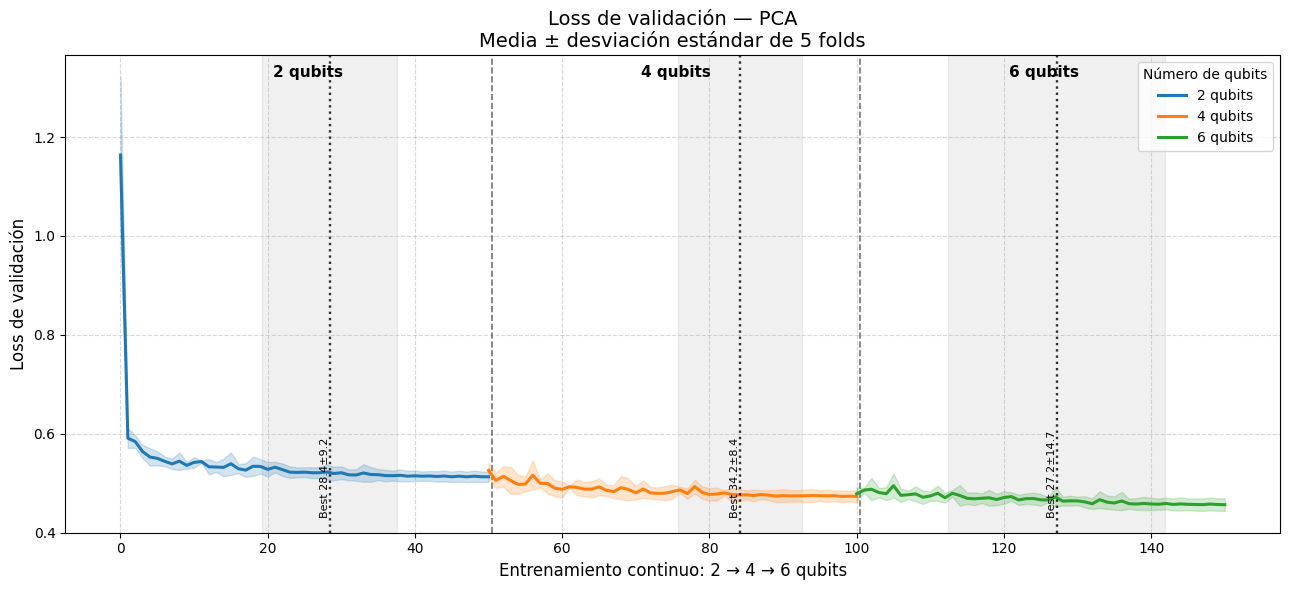

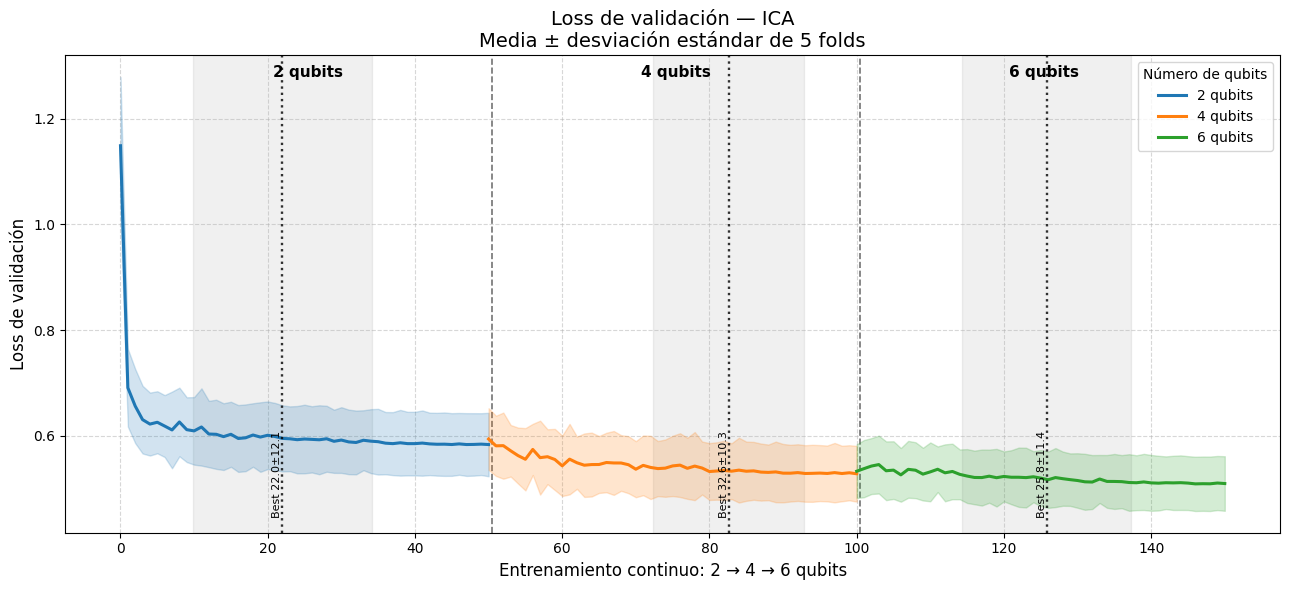

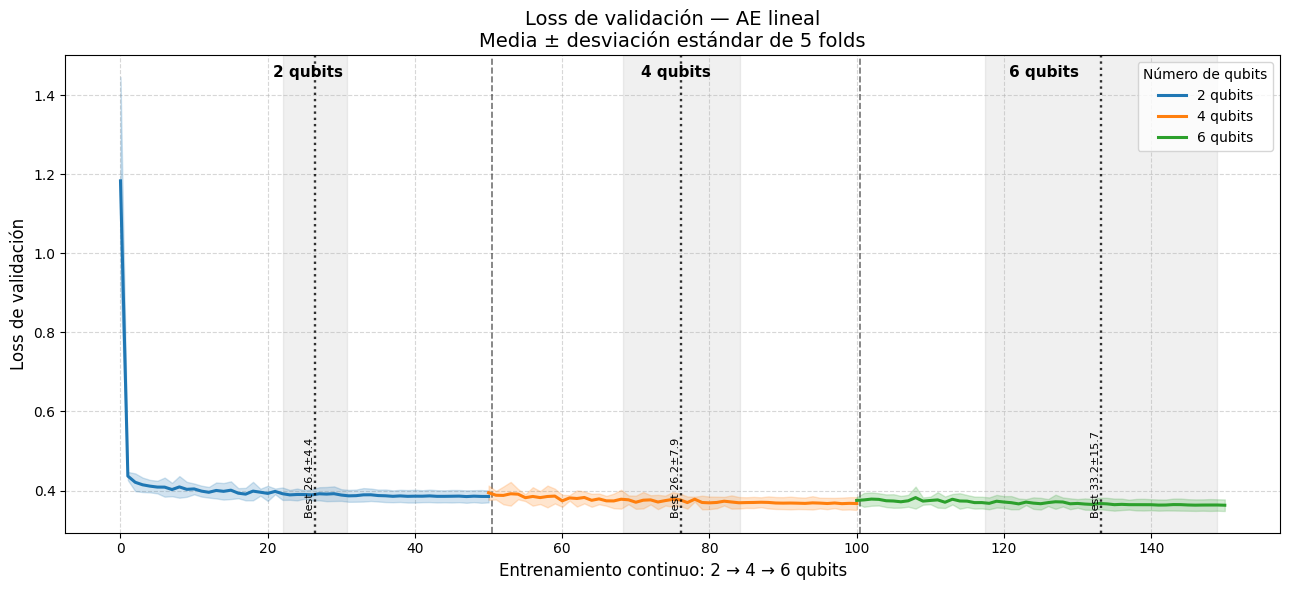

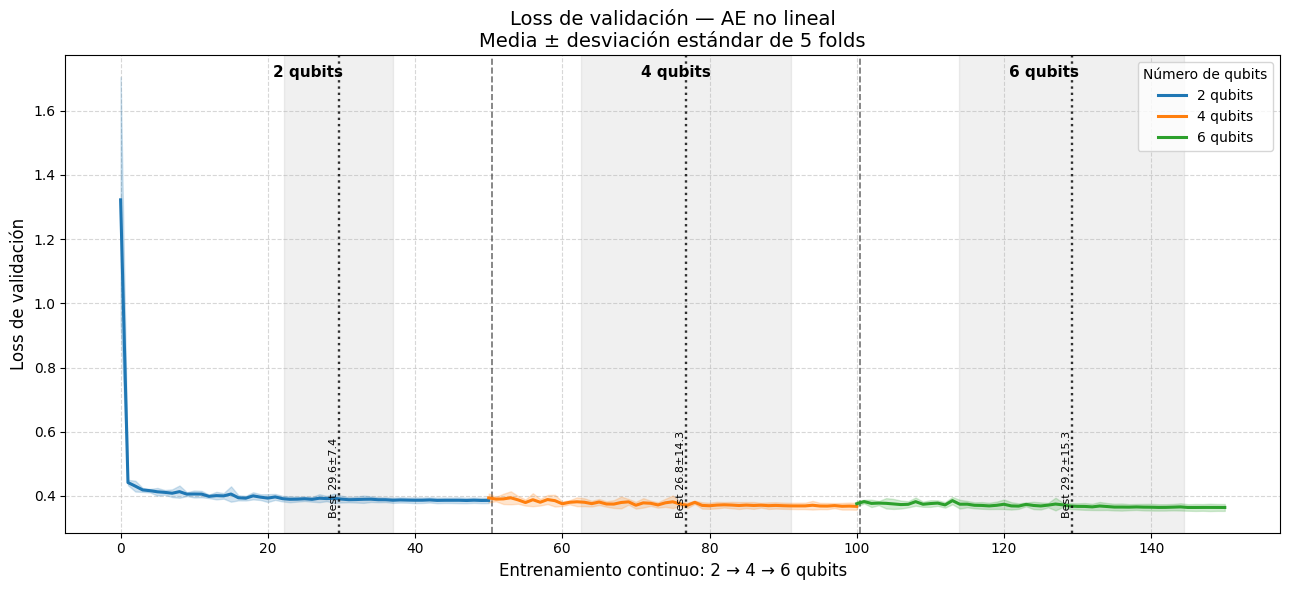

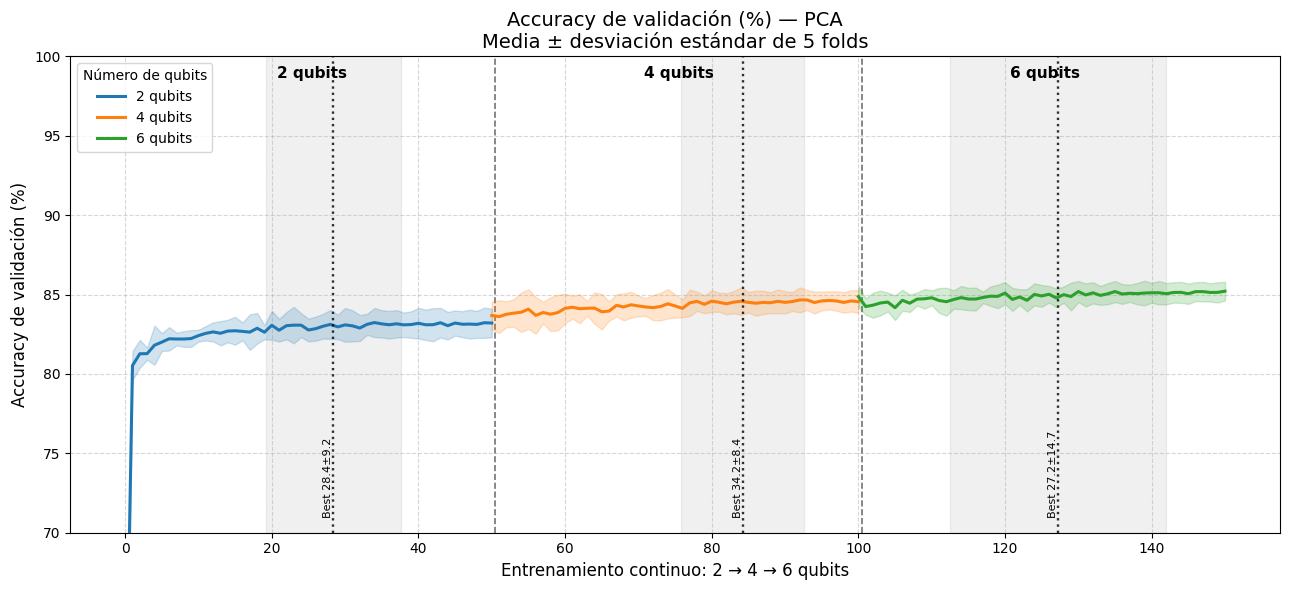

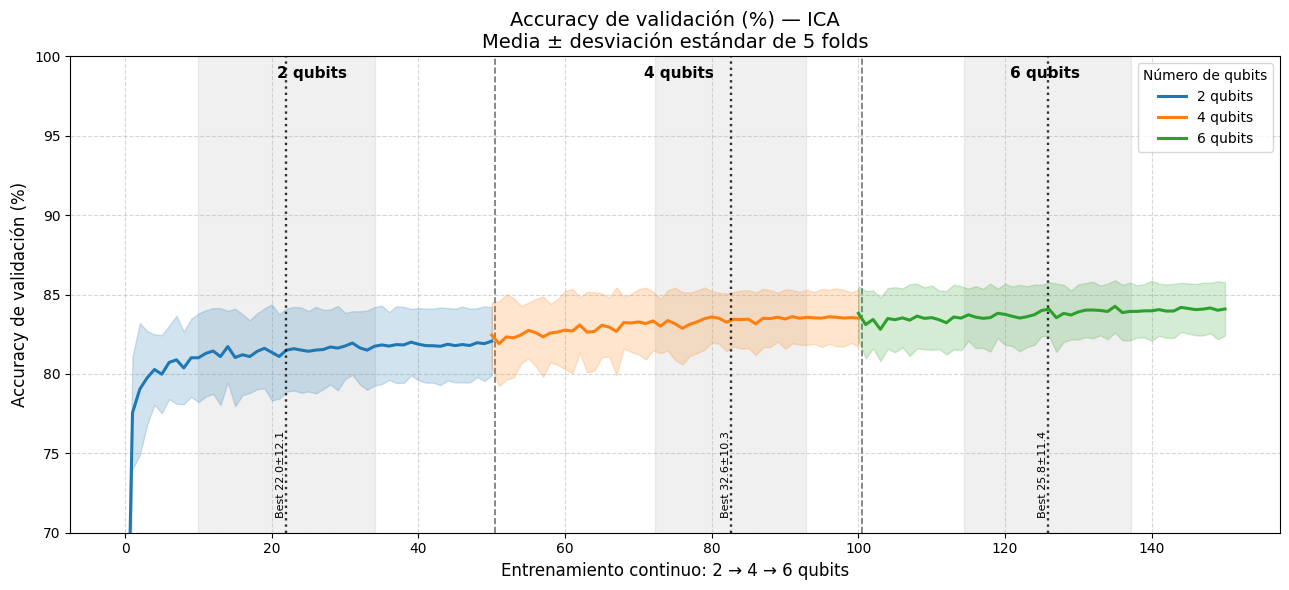

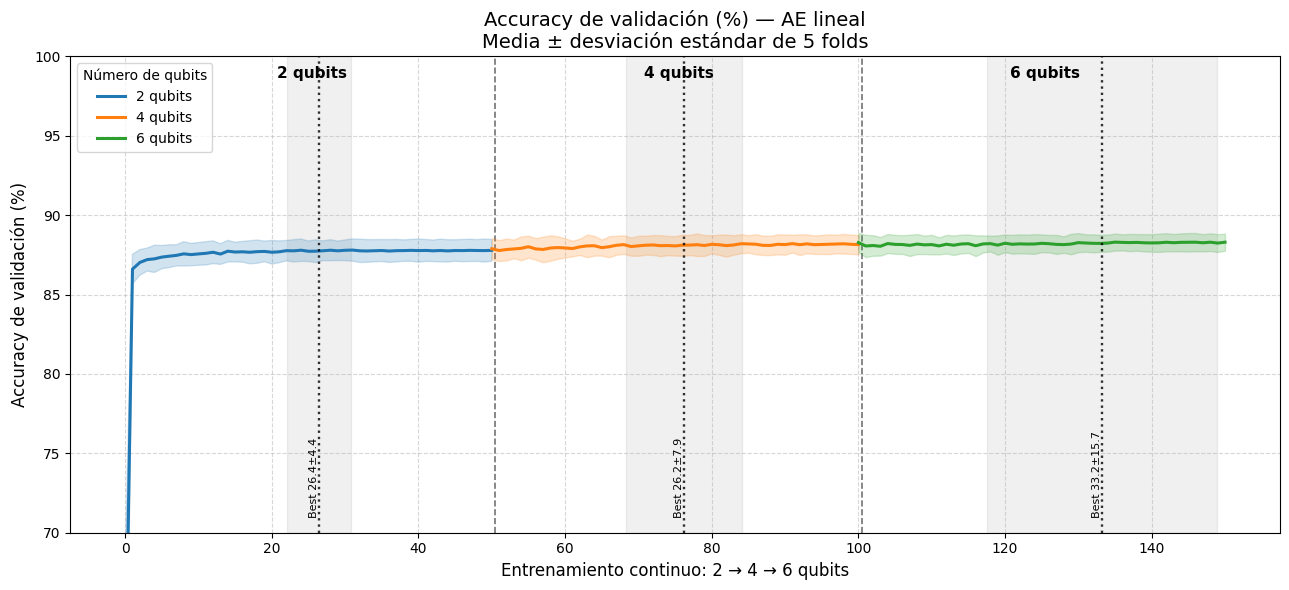

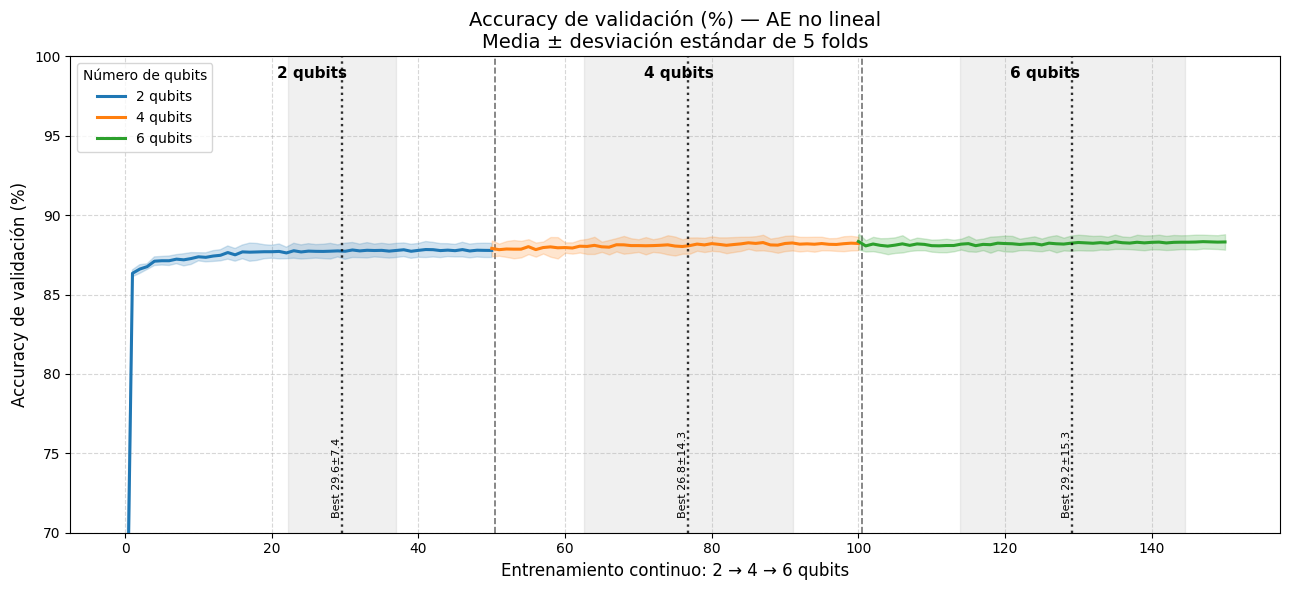

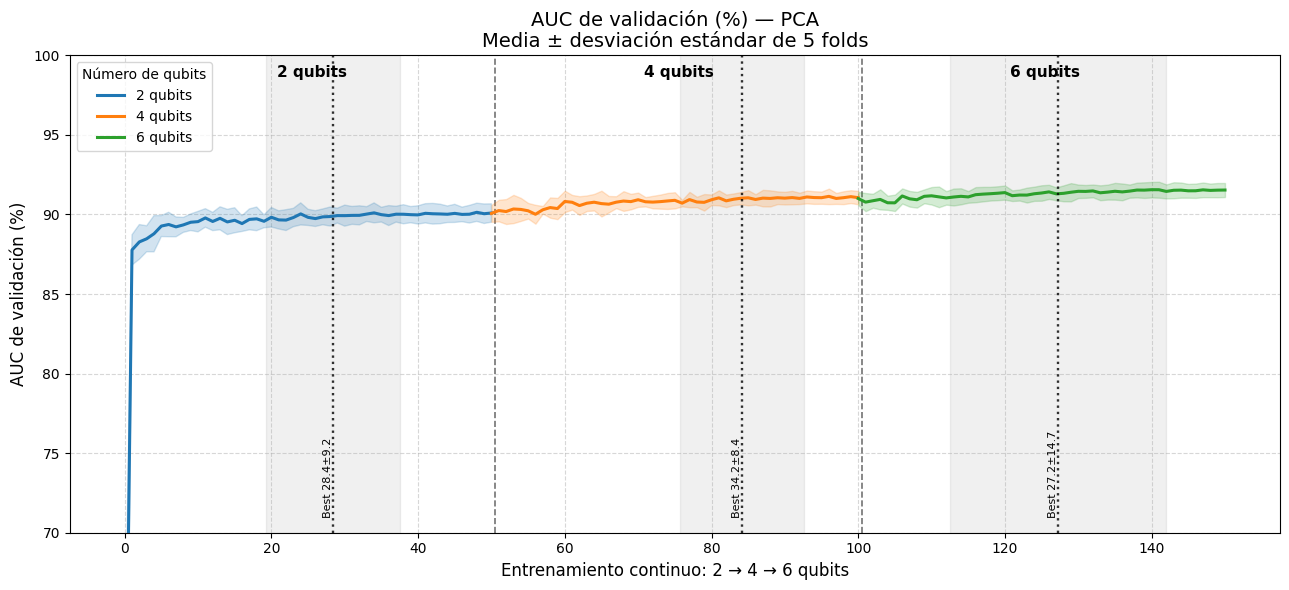

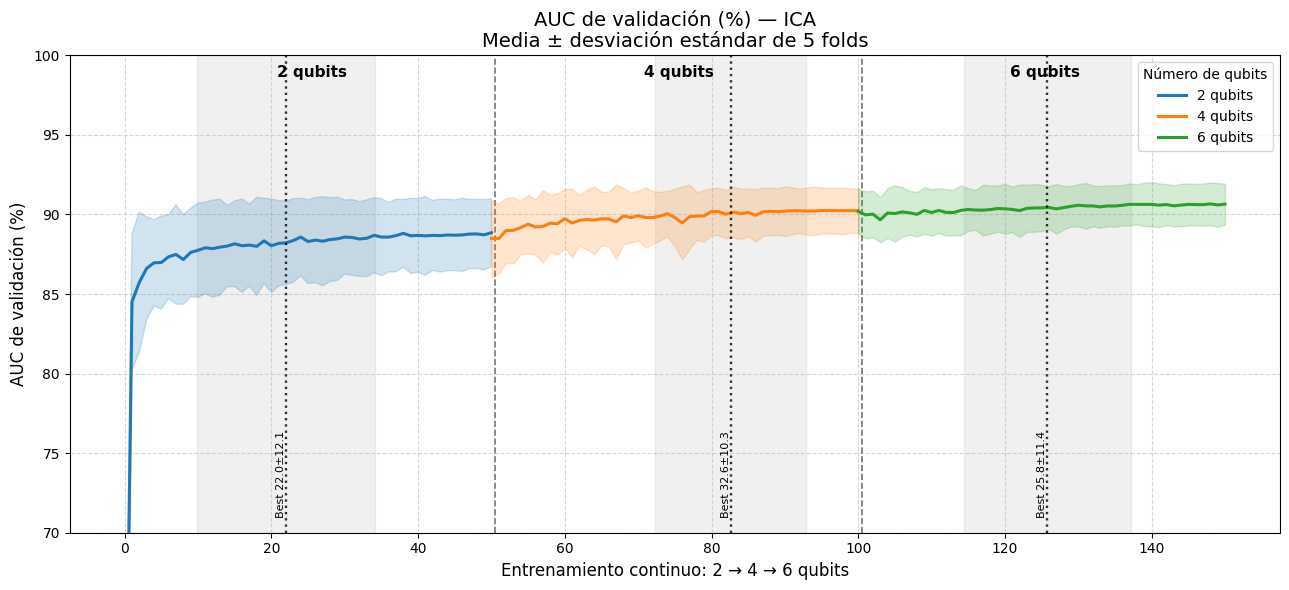

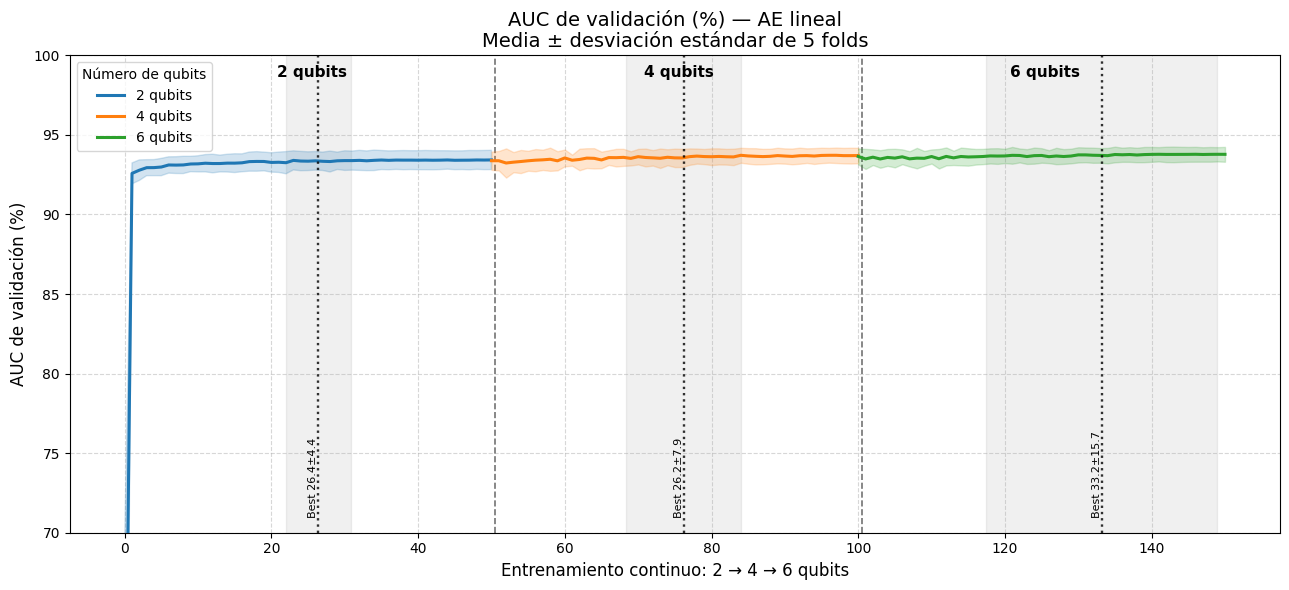

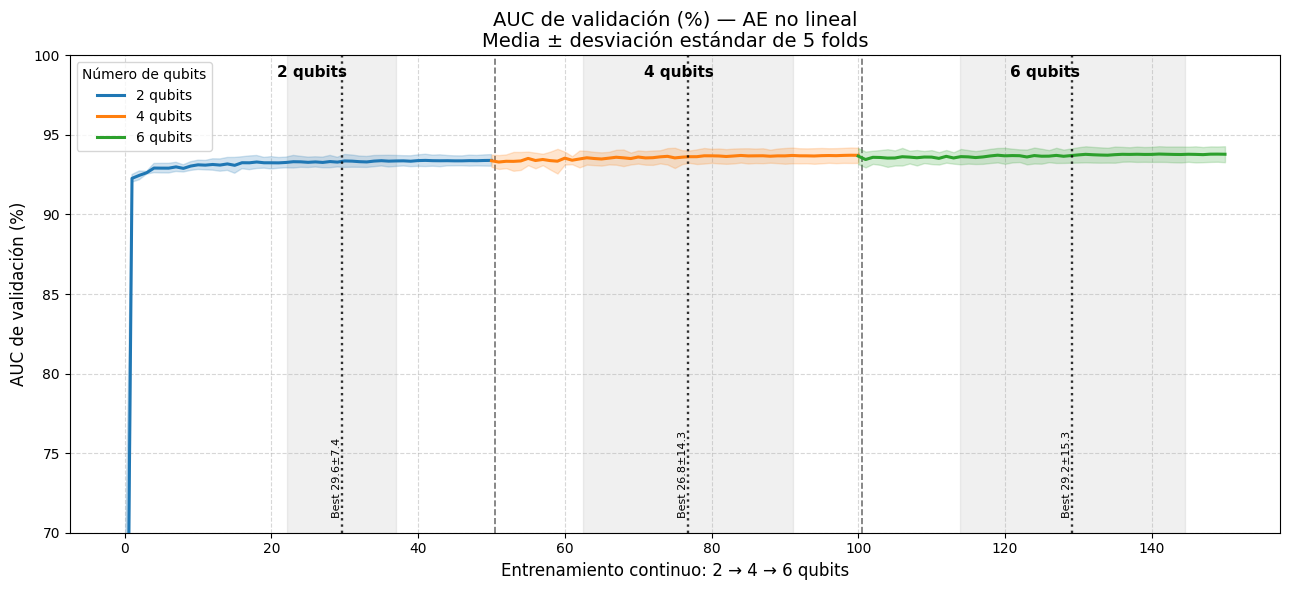

In [11]:
# ============================================================
# CELDA 11 — GRÁFICAS INDIVIDUALES
# ============================================================

for metric in ["loss", "acc", "auc"]:

    if metric not in histories_df.columns:

        print(
            f"[AVISO] No existe la métrica: {metric}"
        )

        continue


    for transformation in TRANSFORMATIONS_ORDER:

        aggregated = aggregate_metric(
            transformation,
            metric,
        )

        fig, ax = plt.subplots(
            figsize=(13, 6)
        )


        for qubits in QUBITS:

            q_data = (
                aggregated[
                    aggregated["qubits"] == qubits
                ]
                .sort_values("continuous_epoch")
            )

            x = q_data[
                "continuous_epoch"
            ].to_numpy()

            mean = q_data[
                "mean"
            ].to_numpy()

            std = q_data[
                "std"
            ].to_numpy()


            line, = ax.plot(
                x,
                mean,
                linewidth=2.2,
                label=f"{qubits} qubits",
                zorder=3,
            )

            ax.fill_between(
                x,
                mean - std,
                mean + std,
                color=line.get_color(),
                alpha=0.20,
                zorder=2,
            )


        ax.set_title(
            f"{METRIC_LABELS[metric]} — {transformation}\n"
            "Media ± desviación estándar de 5 folds",
            fontsize=14,
        )

        finish_axis(ax, metric)

        add_best_epoch_markers(
            ax,
            transformation,
            color="black",
            show_text=True,
        )

        ax.legend(
            title="Número de qubits",
            loc="best",
        )

        plt.tight_layout()
        plt.show()
        plt.close(fig)

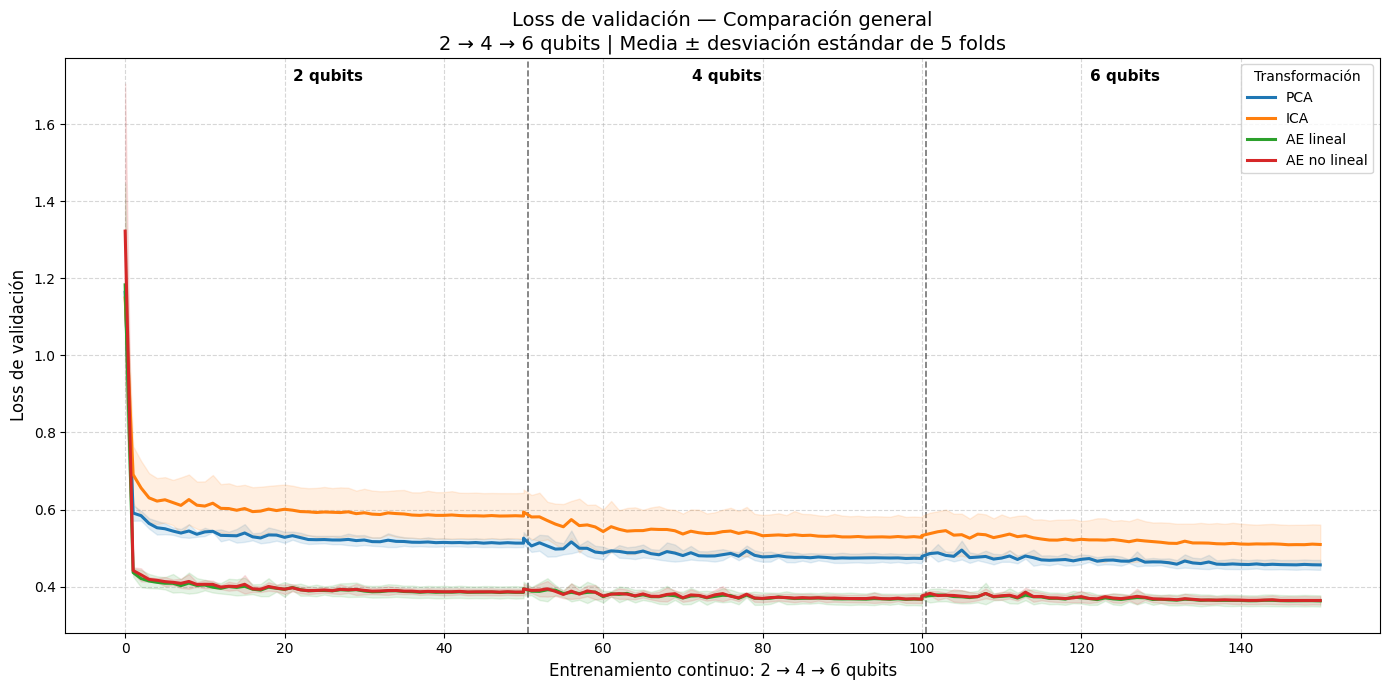

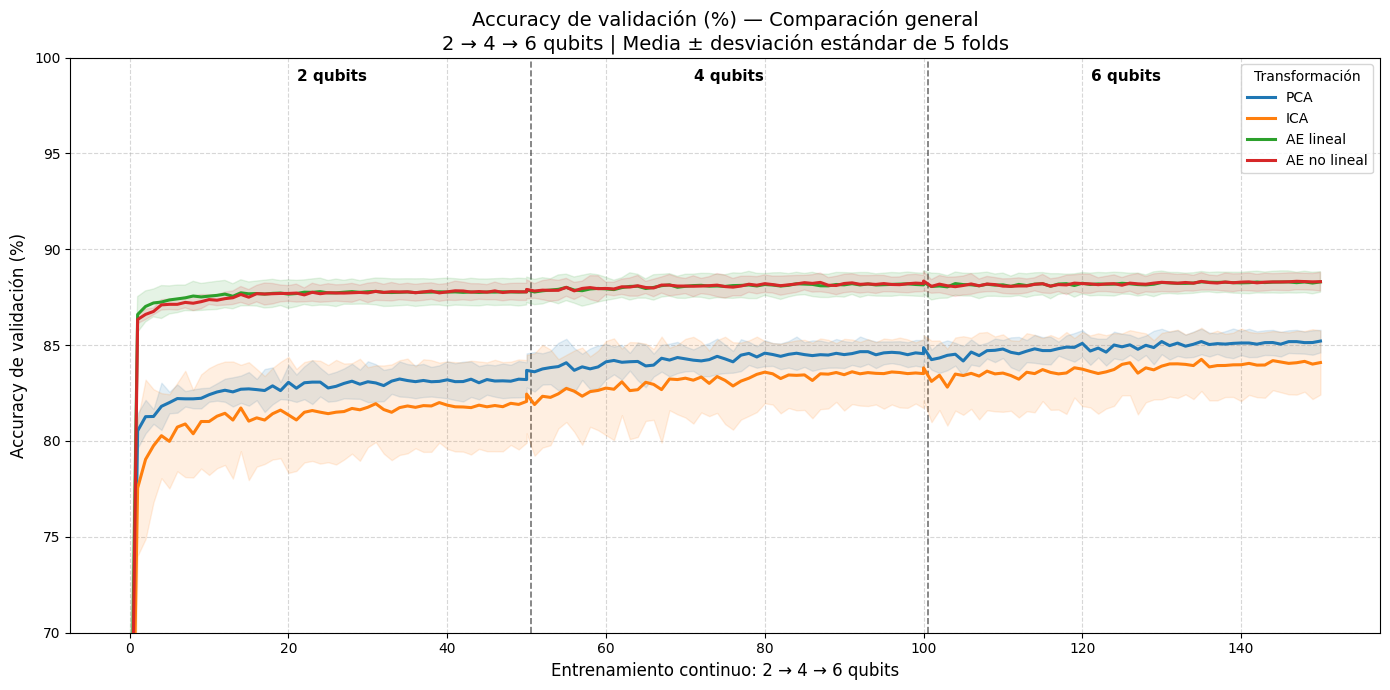

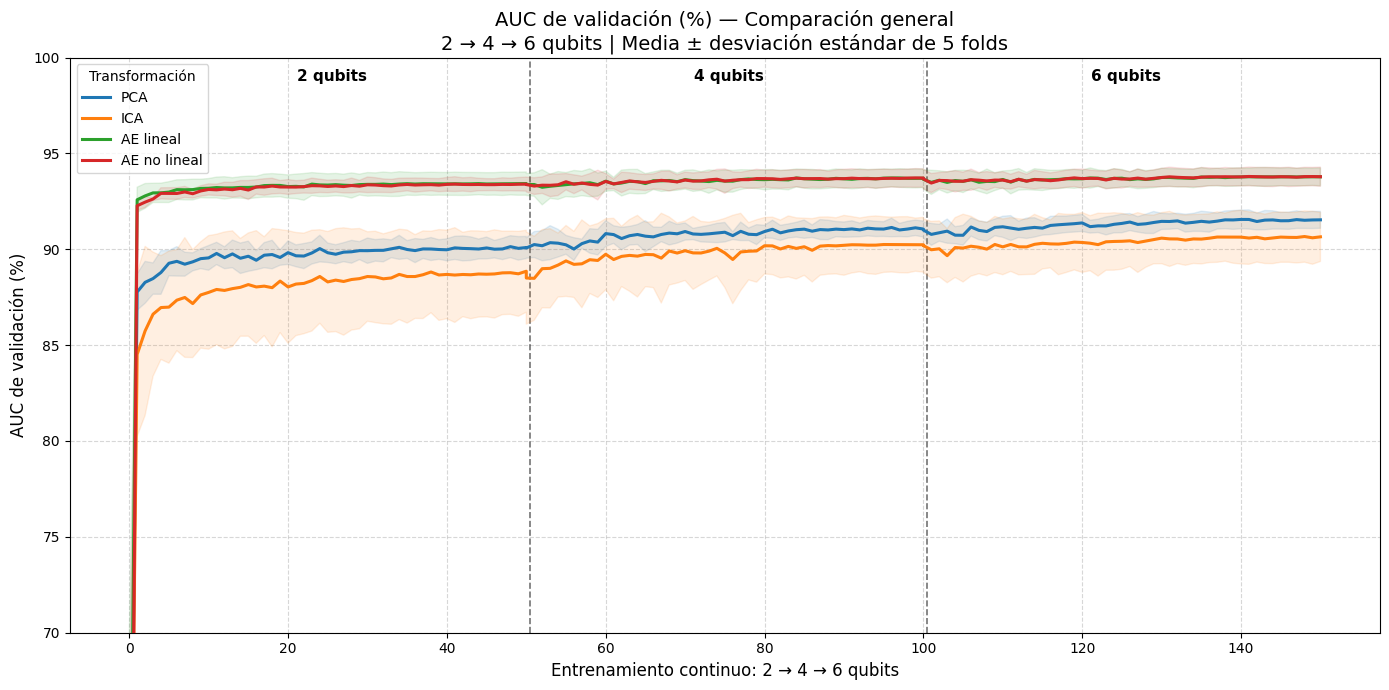

In [12]:
# ============================================================
# CELDA 12 — COMPARACIÓN GENERAL
# ============================================================

for metric in ["loss", "acc", "auc"]:

    if metric not in histories_df.columns:
        continue


    fig, ax = plt.subplots(
        figsize=(14, 7)
    )


    for transformation in TRANSFORMATIONS_ORDER:

        aggregated = aggregate_metric(
            transformation,
            metric,
        )


        x_complete = []
        mean_complete = []
        std_complete = []


        for qubits in QUBITS:

            q_data = (
                aggregated[
                    aggregated["qubits"] == qubits
                ]
                .sort_values("continuous_epoch")
            )

            x_complete.extend(
                q_data["continuous_epoch"].tolist()
            )

            mean_complete.extend(
                q_data["mean"].tolist()
            )

            std_complete.extend(
                q_data["std"].tolist()
            )


        x_complete = np.asarray(x_complete)
        mean_complete = np.asarray(mean_complete)
        std_complete = np.asarray(std_complete)


        line, = ax.plot(
            x_complete,
            mean_complete,
            linewidth=2.2,
            label=transformation,
            zorder=3,
        )


        ax.fill_between(
            x_complete,
            mean_complete - std_complete,
            mean_complete + std_complete,
            color=line.get_color(),
            alpha=0.12,
            zorder=2,
        )


    ax.set_title(
        f"{METRIC_LABELS[metric]} — Comparación general\n"
        "2 → 4 → 6 qubits | Media ± desviación estándar de 5 folds",
        fontsize=14,
    )

    finish_axis(ax, metric)

    ax.legend(
        title="Transformación",
        loc="best",
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [13]:
# ============================================================
# CELDA 13 — RESUMEN DE BEST EPOCH
# ============================================================

best_epoch_summary = (
    best_epochs_df
    .groupby(
        ["transformation", "qubits"],
        as_index=False,
    )
    .agg(
        best_epoch_mean=(
            "best_epoch",
            "mean",
        ),

        best_epoch_std=(
            "best_epoch",
            "std",
        ),

        best_epoch_min=(
            "best_epoch",
            "min",
        ),

        best_epoch_max=(
            "best_epoch",
            "max",
        ),

        n_folds=(
            "best_epoch",
            "count",
        ),
    )
)

display(best_epoch_summary)

,transformation,qubits,best_epoch_mean,best_epoch_std,best_epoch_min,best_epoch_max,n_folds
0,AE lineal,2,26.4,4.393177,20,31,5
1,AE lineal,4,26.2,7.886698,18,35,5
2,AE lineal,6,33.2,15.722595,8,48,5
3,AE no lineal,2,29.6,7.402702,17,35,5
4,AE no lineal,4,26.8,14.254824,3,37,5
5,AE no lineal,6,29.2,15.319922,9,50,5
6,ICA,2,22.0,12.103718,12,40,5
7,ICA,4,32.6,10.310189,19,46,5
8,ICA,6,25.8,11.432410,7,35,5
9,PCA,2,28.4,9.154234,15,37,5
